# Proyek Analisis Data: Air Quality
- **Nama:** Puguh Setya Wibowo
- **Email:** cdcc284d6y2153@student.devacademy.id
- **ID Dicoding:** cdcc284d6y2153

Data Understanding

Dataset ini berisi data kualitas udara dari beberapa stasiun pengamatan yang mencakup parameter polutan serta kondisi meteorologi.

Variabel Waktu
- year: Tahun pengamatan data  
- month: Bulan pengamatan  
- day: Tanggal pengamatan  
- hour: Jam pengamatan (0–23)  

Variabel Polutan Udara
- PM2.5: Partikel udara berukuran ≤2.5 mikrometer, indikator utama kualitas udara  
- PM10: Partikel udara berukuran ≤10 mikrometer  
- SO2: Gas hasil pembakaran bahan bakar fosil  
- NO2: Gas dari kendaraan dan aktivitas industri  
- CO: Gas beracun akibat pembakaran tidak sempurna  
- O3: Ozon permukaan yang terbentuk dari reaksi kimia di atmosfer  

Variabel Meteorologi
- TEMP: Suhu udara (°C)  
- PRES: Tekanan udara  
- DEWP: Titik embun (indikator kelembaban)  
- RAIN: Curah hujan (mm)  

Variabel Angin
- wd: Arah angin  
- WSPM: Kecepatan angin (m/s)  

Variabel Lokasi
- station: Nama stasiun pengamatan  

Variabel Tambahan
- No: Nomor urut data (index)

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh curah hujan (RAIN) terhadap perubahan konsentrasi polutan (PM2.5, PM10, NO2, SO2, CO, dan O3) di seluruh lokasi pengamatan selama periode 2013–2017 ?
- Bagaimana distribusi tingkat polusi di setiap station berdasarkan rata-rata masing-masing polutan selama periode 2013–2017?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd
import glob


## Data Wrangling

### Gathering Data



**mengumpulkan data jadi satu**

In [ ]:

files = glob.glob('PRSA_Data_*.csv')
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.shape

(420768, 18)

**membaca csv**

In [ ]:
df.to_csv('kumpulan_data.csv', index=False)

In [ ]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Data berasal dari beberapa lokasi yang berbeda dilihat dari _station_
- Data yang  digunakan bersifat time series sehingga bisa kita lanjutkan dengan forecasting
- Data mempunyai struktur kolom yang sama

### Assessing Data

**melihat informasi kolom**

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 57.8 MB


**melihat distribusi data**

In [ ]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


Berdasarkan hasil statistik deskriptif, tidak ditemukan nilai negatif pada variabel polutan sehingga data dapat dikatakan valid secara umum. Namun, terdapat beberapa nilai ekstrem pada variabel seperti PM2.5, PM10, CO, dan O3 yang menunjukkan adanya outlier.

Selain itu, perbedaan antara nilai mean dan median menunjukkan bahwa distribusi data cenderung tidak normal (skewed) dengan variasi yang cukup besar. Sementara itu, variabel meteorologi seperti suhu, tekanan, dan kelembaban masih berada dalam rentang yang wajar.

**cek nilai kosong**

In [ ]:
df.isnull().sum()


No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

**cek banyak data**

In [ ]:
# cek total baris
total_baris = df.shape[0]
print(f'Total baris: {total_baris}')

Total baris: 420768


**cek distribusi banyak data per station**

In [ ]:
# cek total baris per station
df.groupby('station').size().reset_index(name='jumlah_data')

,station,jumlah_data
0,Aotizhongxin,35064
1,Changping,35064
2,Dingling,35064
3,Dongsi,35064
4,Guanyuan,35064
5,Gucheng,35064
6,Huairou,35064
7,Nongzhanguan,35064
8,Shunyi,35064
9,Tiantan,35064


**cek nilai kosong data per stasion**

In [ ]:
df.groupby('station').apply(lambda x: x.isnull().sum())

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
station,,,,,,,,,,,,,,,,,
Aotizhongxin,0,0,0,0,0,925,718,935,1023,1776,1719,20,20,20,20,81,14
Changping,0,0,0,0,0,774,582,628,667,1521,604,53,50,53,51,140,43
Dingling,0,0,0,0,0,779,656,730,1234,2012,1214,53,50,53,51,140,43
Dongsi,0,0,0,0,0,750,553,663,1601,3197,664,20,20,20,20,78,14
Guanyuan,0,0,0,0,0,616,429,474,659,1753,1173,20,20,20,20,81,14
Gucheng,0,0,0,0,0,646,381,507,668,1401,729,51,50,51,43,159,42
Huairou,0,0,0,0,0,953,777,980,1639,1422,1151,51,53,53,55,302,49
Nongzhanguan,0,0,0,0,0,628,440,446,692,1206,506,20,20,20,20,78,14
Shunyi,0,0,0,0,0,913,548,1296,1365,2178,1489,51,51,54,51,483,44


Dari  data di atas bisa kita lihat kalau data kosong per station
contoh  station  Dongsi, PM2.5 tedapat kolom kosong  sebanyak 750

In [ ]:
persentase_kolom_kosong = df.groupby('station').apply(lambda x: x.isnull().mean() * 100)
persentase_kolom_kosong

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
station,,,,,,,,,,,,,,,,,
Aotizhongxin,0.0,0.0,0.0,0.0,0.0,2.638033,2.047684,2.666553,2.917522,5.065024,4.902464,0.057039,0.057039,0.057039,0.057039,0.231006,0.039927
Changping,0.0,0.0,0.0,0.0,0.0,2.207392,1.659822,1.791011,1.902236,4.337782,1.722564,0.151152,0.142596,0.151152,0.145448,0.399270,0.122633
Dingling,0.0,0.0,0.0,0.0,0.0,2.221652,1.870865,2.081907,3.519279,5.738079,3.462240,0.151152,0.142596,0.151152,0.145448,0.399270,0.122633
Dongsi,0.0,0.0,0.0,0.0,0.0,2.138946,1.577116,1.890828,4.565937,9.117614,1.893680,0.057039,0.057039,0.057039,0.057039,0.222450,0.039927
Guanyuan,0.0,0.0,0.0,0.0,0.0,1.756788,1.223477,1.351814,1.879420,4.999430,3.345311,0.057039,0.057039,0.057039,0.057039,0.231006,0.039927
Gucheng,0.0,0.0,0.0,0.0,0.0,1.842345,1.086585,1.445927,1.905088,3.995551,2.079055,0.145448,0.142596,0.145448,0.122633,0.453457,0.119781
Huairou,0.0,0.0,0.0,0.0,0.0,2.717887,2.215948,2.794889,4.674310,4.055441,3.282569,0.145448,0.151152,0.151152,0.156856,0.861282,0.139744
Nongzhanguan,0.0,0.0,0.0,0.0,0.0,1.791011,1.254848,1.271960,1.973534,3.439425,1.443076,0.057039,0.057039,0.057039,0.057039,0.222450,0.039927
Shunyi,0.0,0.0,0.0,0.0,0.0,2.603810,1.562856,3.696099,3.892882,6.211499,4.246521,0.145448,0.145448,0.154004,0.145448,1.377481,0.125485


Dari data diatas persentase kosong tidak sampai 10% lebih agar lebih efisien kita isi dengan median untuk menghindari outliers dan untuk WD kita isi dengn mode per Station

**cek duplikasi data**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight:**
- Data kosong per station tidak sampai 10% hal tersebut bisa diatasi dengan mengisi mean/median/mode
- Data terdapat outliers, distribusi tidak normal

### Cleaning Data

**drop kolom nomor**

In [ ]:
df.drop(columns=['No'], inplace=True)

**mengisi data kosong**

In [ ]:
# mengisi kolom numerik dengan median per station
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df.groupby('station')[num_cols].transform(lambda x: x.fillna(x.median()))

# mengisi kolom kategori dengan modus per station
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.fillna(x.mode()[0]))

data numeric diambil dengan melihat kolom "numeric" lalu megisinya denga median

data kategori karena hanya satu lngsung saya ambil kolom "wd" saja isi dengan mode

In [ ]:
df.isnull().sum()

year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [ ]:
df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,2014.662560,6.522930,15.729637,11.500000,79.273026,104.235659,15.642997,50.384959,1212.909829,56.925748,13.539869,1010.746005,2.491120,0.064416,1.729444
std,1.177198,3.448707,8.800102,6.922195,80.064127,91.123375,21.456742,34.714968,1134.271612,55.830557,11.430772,10.469428,13.787259,0.820626,1.245961
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,2014.000000,4.000000,8.000000,5.750000,21.000000,36.000000,3.000000,23.000000,500.000000,12.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,2016.000000,10.000000,23.000000,17.250000,109.000000,144.000000,19.000000,70.000000,1500.000000,80.000000,23.200000,1019.000000,15.100000,0.000000,2.200000
max,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**mengatasi outliers**

untuk mengatasi masalah outliers yang ada di data  dapat digunakan IQR

In [ ]:
kolom = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','WSPM']

for col in kolom:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    minimal = Q1 - 1.5 * IQR
    maksimal = Q3 + 1.5 * IQR

    df[col] = df[col].clip(minimal, maksimal)

In [ ]:
df.describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,2014.662560,6.522930,15.729637,11.500000,75.305516,100.886785,13.137568,49.953605,1114.658722,55.076284,13.539869,1010.746005,2.491120,0.064416,1.668189
std,1.177198,3.448707,8.800102,6.922195,66.821178,79.168282,13.416525,33.303186,805.379431,49.960014,11.430772,10.469428,13.787259,0.820626,1.061947
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,2014.000000,4.000000,8.000000,5.750000,21.000000,36.000000,3.000000,23.000000,500.000000,12.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,2016.000000,10.000000,23.000000,17.250000,109.000000,144.000000,19.000000,70.000000,1500.000000,80.000000,23.200000,1019.000000,15.100000,0.000000,2.200000
max,2017.000000,12.000000,31.000000,23.000000,241.000000,306.000000,43.000000,140.500000,3000.000000,182.000000,41.600000,1042.800000,29.100000,72.500000,4.150000


In [ ]:
#df.to_csv('kumpulan_data_bersih.csv', index=False)

Karena masih ada outliers saya menggunakan IQR untuk menangani outiers. Hasilnya outliers dalam data sudah berkurang banyak

**mengonversi ke timeseries**

In [ ]:
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

**Insight:**
- Data telah bersih
- Outliers  telah  berkurang  banyak
- Pengubahan kolom tahun bulan dan tanggal menjadi timeseries

## Exploratory Data Analysis (EDA)

### Explore all data

In [ ]:
df['rain_category'] = df['RAIN'].apply(lambda x: 'Hujan' if x > 0 else 'Tidak Hujan')


In [ ]:
pollutants = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]

In [ ]:
df[['RAIN','PM2.5','PM10','NO2','SO2','CO','O3']].describe()

,RAIN,PM2.5,PM10,NO2,SO2,CO,O3
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,0.064416,75.305516,100.886785,49.953605,13.137568,1114.658722,55.076284
std,0.820626,66.821178,79.168282,33.303186,13.416525,805.379431,49.960014
min,0.000000,2.000000,2.000000,1.026500,0.285600,100.000000,0.214200
25%,0.000000,21.000000,36.000000,23.000000,3.000000,500.000000,12.000000
50%,0.000000,55.000000,82.000000,43.000000,7.000000,900.000000,44.000000
75%,0.000000,109.000000,144.000000,70.000000,19.000000,1500.000000,80.000000
max,72.500000,241.000000,306.000000,140.500000,43.000000,3000.000000,182.000000


Nilai rata-rata curah hujan sangat rendah yaitu sebesar 0.064, dengan median 0.0

Nilai kuartil (25%, 50%, 75%) semuanya 0.0, menunjukkan bahwa sebagian besar waktu tidak terjadi hujan.

Hal ini mengindikasikan bahwa kejadian hujan relatif jarang dibandingkan kondisi tidak hujan dalam dataset.

In [ ]:
cols = ['RAIN','PM2.5','PM10','NO2','SO2','CO','O3']
df[cols].corr()

,RAIN,PM2.5,PM10,NO2,SO2,CO,O3
RAIN,1.000000,-0.013777,-0.028205,-0.044251,-0.049598,-0.009651,0.027444
PM2.5,-0.013777,1.000000,0.887971,0.656147,0.506623,0.786630,-0.166231
PM10,-0.028205,0.887971,1.000000,0.662164,0.500304,0.706651,-0.130185
NO2,-0.044251,0.656147,0.662164,1.000000,0.528435,0.717968,-0.507148
SO2,-0.049598,0.506623,0.500304,0.528435,1.000000,0.593379,-0.183810
CO,-0.009651,0.786630,0.706651,0.717968,0.593379,1.000000,-0.362173
O3,0.027444,-0.166231,-0.130185,-0.507148,-0.183810,-0.362173,1.000000


Beberapa polutan seperti PM2.5, PM10, dan NO2 memiliki korelasi negatif terhadap curah hujan, yang mengindikasikan adanya kecenderungan penurunan konsentrasi polutan saat curah hujan meningkat.

Namun, kekuatan hubungan yang rendah menunjukkan bahwa curah hujan bukan merupakan faktor utama yang mempengaruhi variasi polusi.

In [ ]:
df['rain_category'] = df['RAIN'].apply(lambda x: 'Hujan' if x > 0 else 'Tidak Hujan')

rain_category berisi data hujan dan tidak

jika 0.0 maka curah hujan 0=tidak hujan  

jika >0.0 maka ada curah hujan = hujan

In [ ]:
df.groupby('rain_category')[['PM2.5','PM10','NO2','SO2','CO','O3']].mean()

,PM2.5,PM10,NO2,SO2,CO,O3
rain_category,,,,,,
Hujan,61.582791,69.532331,37.557223,5.241887,1065.718462,50.560649
Tidak Hujan,75.866309,102.168116,50.460196,13.460233,1116.658714,55.260820


Konsentrasi polutan cenderung lebih rendang ketika hujan dibandingkan dengan ketika tidak terjadi hujan

penurunan paling signifikan terjadi pada PM2.5 dan PM10

Data trend tersebut menunjukkan :
- awal bulan RAIN sedikit naik
- Pertengahan bulan RAIN melonjak naik
- Akhhir bulan RAIN menurun drastis bahkan 0

In [ ]:
mean_station = df.groupby('station')[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].mean()
mean_station

,PM2.5,PM10,NO2,SO2,CO,O3
station,,,,,,
Aotizhongxin,77.855530,105.811679,58.386799,14.198282,1128.994039,53.752707
Changping,68.249749,92.113356,43.884665,12.496012,1051.139659,55.917956
Dingling,63.083074,81.652504,27.220576,10.628255,849.632985,66.167310
Dongsi,80.500088,105.337968,52.995297,15.326458,1196.019878,55.264670
Guanyuan,78.391795,105.318247,57.160886,14.262521,1150.656742,53.573522
Gucheng,78.886784,114.515084,55.212063,13.002787,1192.191421,55.531812
Huairou,66.849190,89.039214,32.088284,10.244491,973.987309,57.494126
Nongzhanguan,79.123888,104.596729,57.315745,15.012202,1182.591747,56.208778
Shunyi,74.891302,95.578303,43.497500,11.410692,1072.165440,53.014520


In [ ]:
mean_station.idxmax()


PM2.5           Dongsi
PM10           Gucheng
NO2             Wanliu
SO2             Dongsi
CO       Wanshouxigong
O3            Dingling
dtype: str

## Visualization & Explanatory Analysis

### Pertanyaan 1:

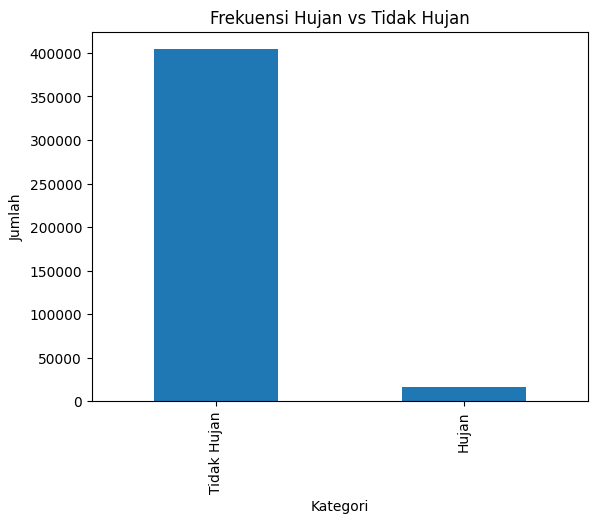

In [ ]:
rain_count = df['rain_category'].value_counts()

plt.figure()
rain_count.plot(kind='bar')
plt.title('Frekuensi Hujan vs Tidak Hujan')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.show()

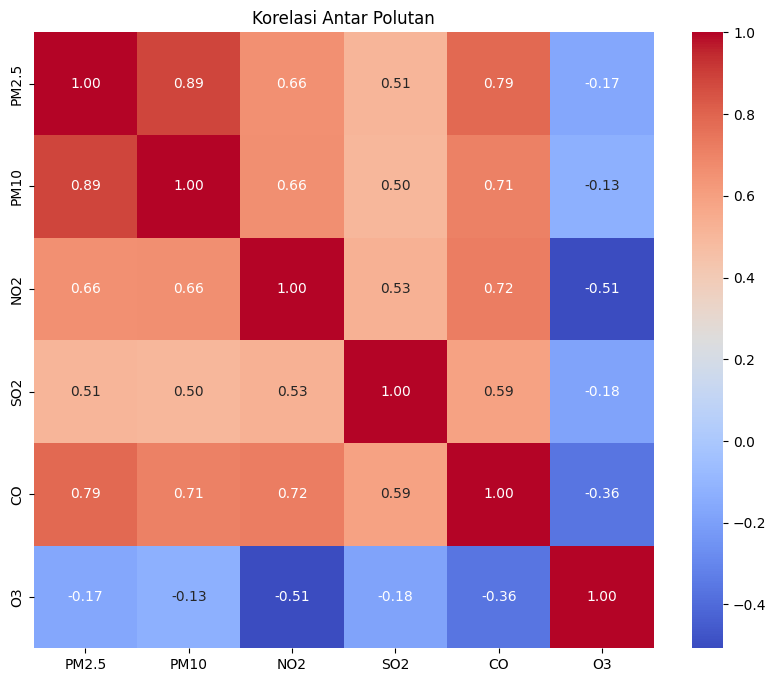

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(pollutants.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi Antar Polutan')
plt.show()

Grafik diatas saling berkorelasi antar  polutan, terutama partikel PM2.5 dan PM110. Hanya O3 yang tidak berkorelasi antar polutan

In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

mean_df = df.groupby('rain_category')[pollutants].mean()


diff = mean_df.loc['Tidak Hujan'] - mean_df.loc['Hujan']
diff = diff.sort_values(ascending=False)
diff

CO       50.940252
PM10     32.635786
PM2.5    14.283518
NO2      12.902973
SO2       8.218347
O3        4.700171
dtype: float64

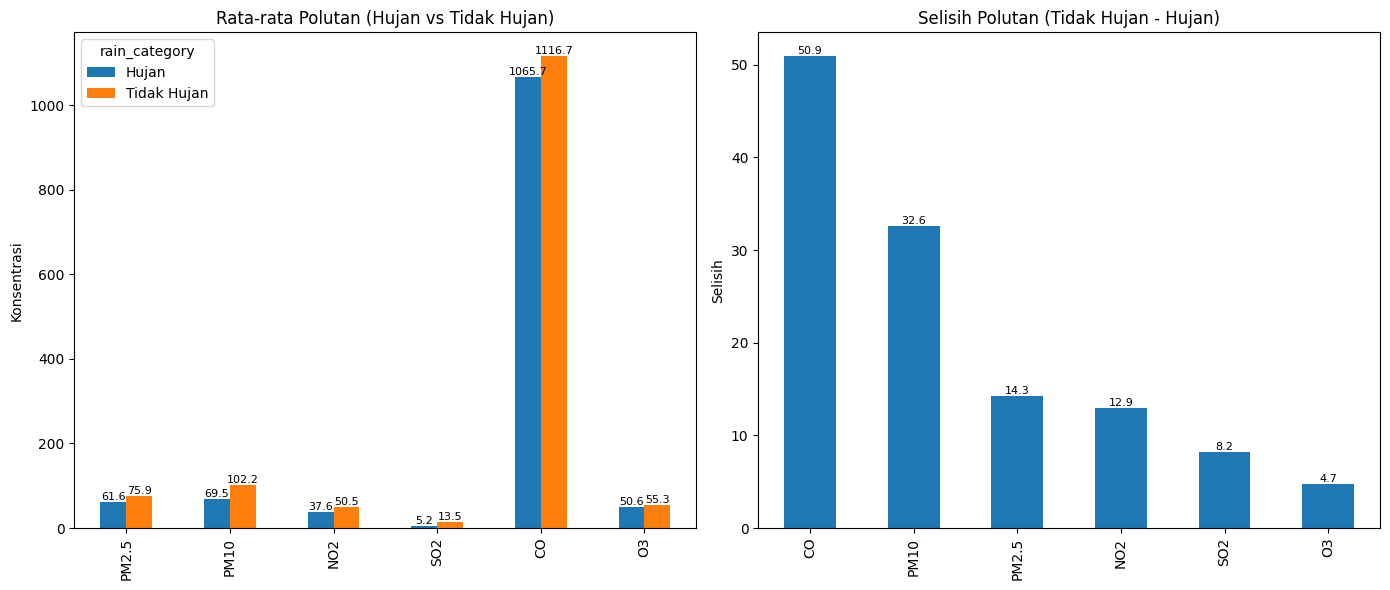

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,6))

mean_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Rata-rata Polutan (Hujan vs Tidak Hujan)')
axes[0].set_ylabel('Konsentrasi')
# untuk menampilkan nilai di atas batang
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)
# menampilkan selisih
diff.plot(kind='bar', ax=axes[1])
axes[1].set_title('Selisih Polutan (Tidak Hujan - Hujan)')
axes[1].set_ylabel('Selisih')

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)
sorted_diff = diff.sort_values(ascending=False)
sorted_diff.plot(kind='bar', ax=axes[1])
plt.tight_layout()
plt.show()

Grafik diatas telah menjawab bahwa hujan mempunyai pengaruh penurunan polutan

polutan yang paling mengalami penurunan secara signifikan adalah CO2(karbon dioksida).

Hasilnya RAIN (hujan) dapat menurunkan Polutan khususnya CO2

**Insight:**
1. Data menunjukkan bahwa kondisi tidak hujan mendominasi sebagian besar pengamatan, sehingga analisis pengaruh hujan perlu dilakukan melalui perbandingan langsung antara kondisi hujan dan tidak hujan.
2. Seluruh polutan memiliki konsentrasi yang lebih tinggi pada kondisi tidak hujan dibandingkan saat hujan, yang menunjukkan bahwa curah hujan berkaitan dengan penurunan tingkat polusi udara.
3. Penurunan paling signifikan terjadi pada polutan CO, diikuti oleh PM10 dan PM2.5, yang mengindikasikan bahwa hujan lebih efektif dalam menurunkan polutan tertentu.
4. Korelasi antar polutan menunjukkan hubungan yang cukup kuat, terutama antara PM2.5, PM10, dan CO, yang mengindikasikan kemungkinan sumber polusi yang sama. Sebaliknya, O3 memiliki hubungan negatif terhadap sebagian besar polutan lain, yang menunjukkan karakteristik yang berbeda.

### Pertanyaan 2:

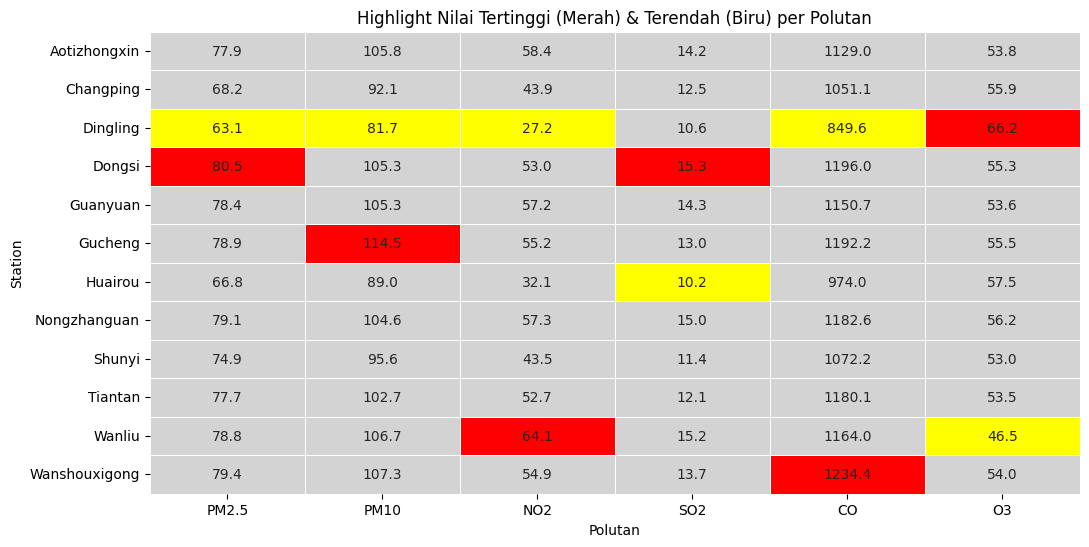

In [ ]:

mask_max = mean_station.eq(mean_station.max())
mask_min = mean_station.eq(mean_station.min())

plt.figure(figsize=(12,6))

sns.heatmap(
    mean_station,
    cmap=['lightgrey'],
    annot=True,
    fmt=".1f",
    cbar=False,
    linewidths=0.5
)

sns.heatmap(
    mean_station,
    mask=~mask_max,
    cmap=['red'],
    annot=False,
    cbar=False,
    linewidths=0.5
)

sns.heatmap(
    mean_station,
    mask=~mask_min,
    cmap=['yellow'],
    annot=False,
    cbar=False,
    linewidths=0.5
)

plt.title('Highlight Nilai Tertinggi (Merah) & Terendah (Biru) per Polutan')
plt.xlabel('Polutan')
plt.ylabel('Station')
plt.show()

**Insight:**

1. Station Dingling cenderung memiliki nilai terendah pada beberapa polutan (PM2.5, PM10, NO2, dan CO), yang mengindikasikan kualitas udara relatif lebih baik dibandingkan station lainnya untuk polutan tersebut.
2. Station Dongsi menunjukkan nilai tertinggi pada beberapa polutan seperti PM2.5 dan SO2, yang mengindikasikan tingkat polusi yang lebih tinggi pada jenis polutan tertentu.
3. Beberapa station lainnya tidak menunjukkan nilai ekstrem (baik tertinggi maupun terendah), yang mengindikasikan bahwa tingkat polusi di lokasi tersebut relatif moderat dan tidak didominasi oleh polutan tertentu.

Artinya setiap polutan memiliki station dengan nilai distribusi berbeda, yang menunjukkan bahwa tingkat polusi tidak terpusat pada satu lokasi tertentu dan kalau dicermati lebih mendalam ketika beberapa polutan tersebut mempunyai titik paling rendah maka O3 menjadi paling tinggi, kemungkinan ada hubungannya dengan ketidak korelasian antara O3 dengan beberapa polutan yang lain

## Analisis Lanjutan (Opsional)

In [ ]:
station_mean = df.groupby(['station','rain_category'])[pollutants].mean().reset_index()

hujan = station_mean[station_mean['rain_category']=='Hujan']
tidak = station_mean[station_mean['rain_category']=='Tidak Hujan']
merged = hujan.merge(tidak, on='station', suffixes=('_hujan','_tidak'))

for pol in pollutants:
    merged[f'diff_{pol}'] = merged[f'{pol}_tidak'] - merged[f'{pol}_hujan']

In [ ]:


long_df = merged.melt(
    id_vars='station',
    value_vars=[f'diff_{pol}' for pol in pollutants],
    var_name='polutan',
    value_name='penurunan'
)

# Ambil terbesar
top = long_df.sort_values(by='penurunan', ascending=False).head(10)
top

,station,polutan,penurunan
53,Gucheng,diff_CO,163.402802
58,Wanliu,diff_CO,150.934309
48,Aotizhongxin,diff_CO,79.978686
59,Wanshouxigong,diff_CO,61.414053
52,Guanyuan,diff_CO,51.614188
56,Shunyi,diff_CO,43.758813
17,Gucheng,diff_PM10,42.111002
22,Wanliu,diff_PM10,38.422612
19,Nongzhanguan,diff_PM10,37.158371
49,Changping,diff_CO,36.482032


- penurunan konsentrasi polutan terbesar akibat hujan terjadi pada polutan CO di beberapa station, dengan nilai tertinggi di station Gucheng, diikuti oleh Wanliu dan Aotizhongxin.

- penurunan juga terlihat pada polutan partikulat seperti PM10, dengan nilai penurunan terbesar juga terjadi di station Gucheng dan Wanliu.
- Konsistensi munculnya station Gucheng dan Wanliu pada beberapa polutan menunjukkan bahwa lokasi tersebut memiliki respons paling kuat terhadap pengaruh hujan dalam menurunkan polusi udara.

**Variasi besarnya penurunan antar station menunjukkan bahwa efektivitas hujan dalam menurunkan polutan dipengaruhi oleh karakteristik lokal masing-masing wilayah.**

In [ ]:
mean_station.sort_values('O3', ascending=False)

,PM2.5,PM10,NO2,SO2,CO,O3
station,,,,,,
Dingling,63.083074,81.652504,27.220576,10.628255,849.632985,66.167310
Huairou,66.849190,89.039214,32.088284,10.244491,973.987309,57.494126
Nongzhanguan,79.123888,104.596729,57.315745,15.012202,1182.591747,56.208778
Changping,68.249749,92.113356,43.884665,12.496012,1051.139659,55.917956
Gucheng,78.886784,114.515084,55.212063,13.002787,1192.191421,55.531812
Dongsi,80.500088,105.337968,52.995297,15.326458,1196.019878,55.264670
Wanshouxigong,79.355450,107.341296,54.850038,13.739651,1234.396190,54.048857
Aotizhongxin,77.855530,105.811679,58.386799,14.198282,1128.994039,53.752707
Guanyuan,78.391795,105.318247,57.160886,14.262521,1150.656742,53.573522


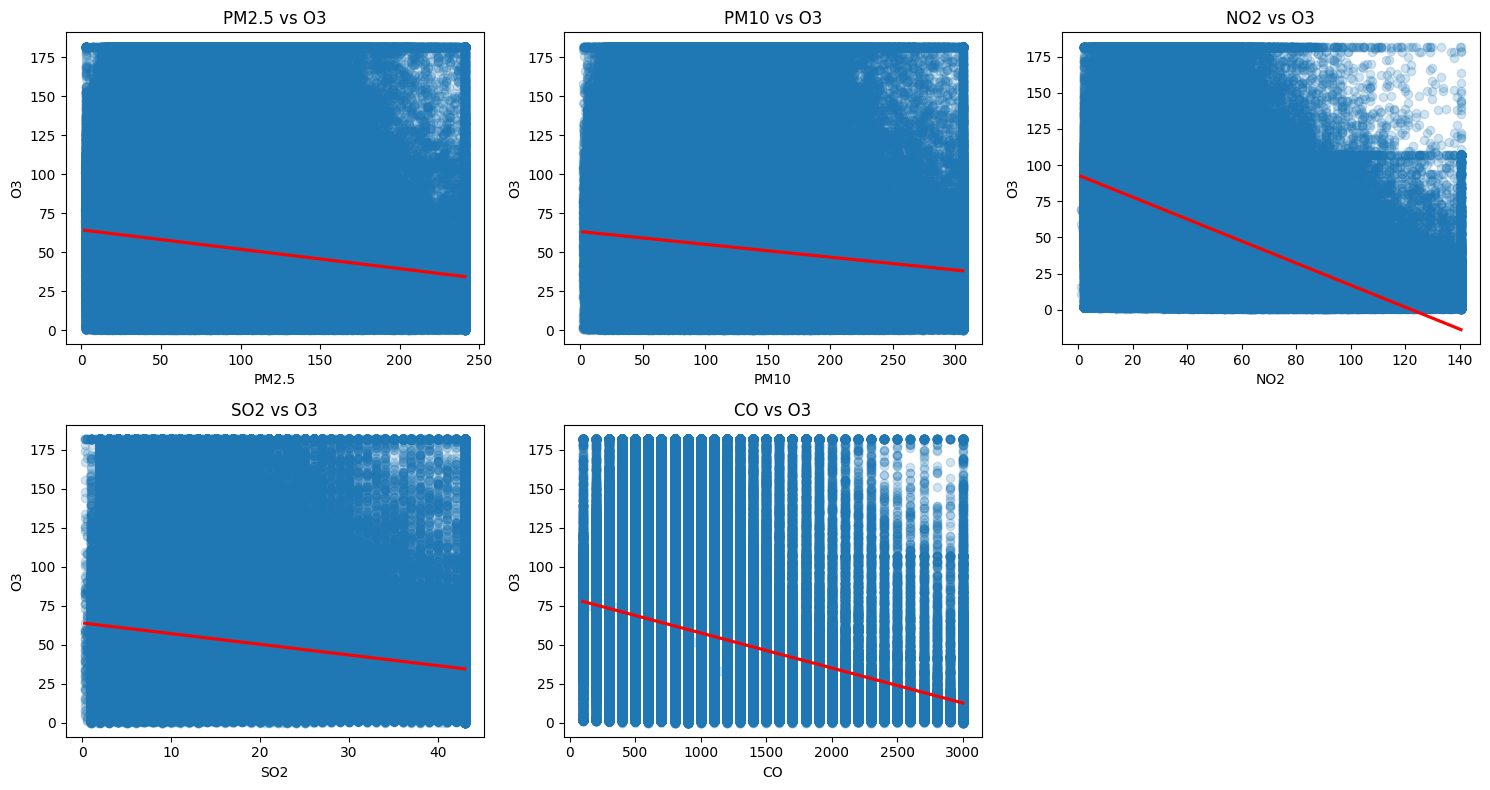

In [ ]:
pollutantsnoco3 = ['PM2.5','PM10','NO2','SO2','CO']

plt.figure(figsize=(15,8))

for i, pol in enumerate(pollutantsnoco3, 1):
    plt.subplot(2,3,i)
    sns.regplot(data=df, x=pol, y='O3',
                scatter_kws={'alpha':0.2},
                line_kws={'color':'red'})
    plt.title(f'{pol} vs O3')

plt.tight_layout()
plt.show()

__NO2 vs O3__

Menunjukkan hubungan negatif yang paling jelas dan kuat
Semakin tinggi NO2, O3 turun signifikan

__CO vs O3__

Hubungan negatif juga terlihat jelas
Pada nilai CO tinggi, O3 cenderung rendah

__PM2.5 & PM10 vs O3__

Tren negatif ada, tetapi lebih lemah dan menyebar
Hubungan tidak sekuat NO2

__SO2 vs O3__

Hubungan negatif terlihat, namun tidak terlalu kuat


Visualisasi menunjukkan adanya kecenderungan hubungan negatif antara O3 dan beberapa polutan lain, terutama NO2 dan CO, di mana peningkatan konsentrasi polutan tersebut diikuti dengan penurunan O3. Hubungan ini tidak bersifat mutlak, namun konsisten terlihat pada keseluruhan data. Artinya sudah terbukti ada penurunan O3 ketika polutan yang lain naik dan kenaikan O3 ketika polutan yang lain menurun.

## Conclusion

Secara keseluruhan, data menunjukkan bahwa kondisi tidak hujan mendominasi dan memiliki konsentrasi polutan yang lebih tinggi dibandingkan saat hujan, sehingga hujan terbukti berkontribusi dalam menurunkan polusi udara, terutama pada CO, PM10, dan PM2.5. Besarnya penurunan yang berbeda antar station menunjukkan bahwa efek hujan dipengaruhi oleh karakteristik lain tiap wilayah. Selain itu, korelasi positif antar polutan seperti PM2.5, PM10, dan CO mengindikasikan kemungkinan sumber yang sama, sementara O3 menunjukkan pola sebaliknya dengan hubungan negatif terhadap polutan lain, terutama NO2 dan CO, yang juga tercermin pada distribusi antar station ketika polutan lain rendah, O3 justru tinggi. Hal ini menegaskan bahwa O3 memiliki karakteristik berbeda dan tidak sejalan dengan polutan lain dalam sistem polusi udara.